# DS11 · Likelihood: state the noise model before fitting

<!-- paper-first -->
### Research question

**Reading:** [PD02](../../curriculum/papers/design.md#pd02), [PM08](../../curriculum/papers/modeling.md#pm08). Review the assigned figure or result before starting the lesson.

**Question:** Which noise assumptions connect a fitted association to the uncertainty attached to it?

Record a prediction, a source location, and one point you want this lesson to clarify. Ask your AI tutor to distinguish the paper’s evidence from its interpretation.
<!-- /paper-first -->

<!-- key-references -->
### Why this technique matters

Choosing a loss function in neuroimaging regression or time-series modeling implicitly specifies a probability distribution for the noise via maximum likelihood estimation. Because head-motion spikes, physiological bursts, and coil glitches generate heavy-tailed residuals, ordinary least squares (Gaussian MLE) suffers unbounded linear influence psi(r) = r/sigma^2, whereas Laplace (L1), Huber, and Student-t likelihoods bound or redescend outlier influence (Huber, 1964; Wager et al., 2005). Simultaneously, likelihood-based criteria (AIC, BIC, cross-validated deviance) are needed to select nuisance drift orders or hidden-state counts without overfitting noise.

**Key references** · *Maximum likelihood estimation (MLE), loss-function equivalence, robust M-estimation (L1/Huber/Student-t), and AIC/BIC model selection*

- *Foundational* — Huber (1964), [Robust Estimation of a Location Parameter](https://doi.org/10.1214/aoms/1177703732), *The Annals of Mathematical Statistics*. Introduces M-estimation and Huber's loss function, bounding the influence function of extreme residuals to bridge quadratic (L2) and absolute-error (L1) estimation.
- *Foundational* — Akaike (1974), [A new look at the statistical model identification](https://doi.org/10.1109/tac.1974.1100705), *IEEE Transactions on Automatic Control*. Establishes the Akaike Information Criterion (AIC = 2k - 2 ln L) from Kullback-Leibler divergence to penalize model complexity when comparing maximum-likelihood fits.
- *Standard tool* — Wager et al. (2005), [Increased sensitivity in neuroimaging analyses using robust regression](https://doi.org/10.1016/j.neuroimage.2005.01.011), *NeuroImage*. Demonstrates that iteratively reweighted least-squares (IRLS) robust regression suppresses outlier artifacts and increases statistical sensitivity in neuroimaging group analyses.
- *Critical evaluation* — Olszowy et al. (2019), [Accurate autocorrelation modeling substantially improves fMRI reliability](https://doi.org/10.1038/s41467-019-09230-w), *Nature Communications*. Evaluates fMRI noise and autocorrelation models across software packages, showing how misspecified noise likelihoods inflate false positives and degrade reliability.

Full entries, verification status and citation counts: [course bibliography](../../curriculum/papers/REFERENCES.md#ds11).
<!-- /key-references -->

**Format:** 75–100 minutes of guided work, plus 30–60 minutes in the assigned existing course material. **Prerequisite:** the foundations notebooks; follow this strand in order. The core exercise is synthetic, offline, and independently runnable. It demonstrates mechanics, not a validated participant-data analysis.

## Existing course material

Read [Neuromatch W1D2 Tutorial2: Linear regression with MLE](https://github.com/NeuromatchAcademy/course-content/blob/44634e960df7a14cd0bf7398187f2d209d26b0e8/tutorials/W1D2_ModelFitting/W1D2_Tutorial2.ipynb). Use the indicated topic, then return here to apply it to a neuroimaging question. Berkeley material is linked in its original form, not adapted or redistributed; its CC BY-NC-ND terms remain upstream. Neuromatch material is CC BY 4.0 with separately licensed software; selected unmodified copies live in `third_party/data_science`. The explanation and dataset below are original.

## Understand the transformation

### 1. Motivation from the Assigned Papers: Why Loss Functions Are Disguised Noise Likelihoods

Every time an analyst or AI script calls `np.polyfit`, `LinearRegression().fit`, or minimizes Mean Squared Error ($\text{MSE}$), they are making a strong, explicit probabilistic claim about the physical noise distribution of the neuroimaging measurement: namely, that residuals are independent and identically distributed **Gaussian** variables with constant variance and light tails. Two landmark papers assigned to this lesson illustrate why stating and auditing the noise likelihood model before fitting is critical:

- **Marek et al. (2022), *Reproducible brain-wide association studies require thousands of individuals* (`PD02`, Main Text & Methods on Motion Artifacts and Phenotypic Associations):** In both individual-level fMRI time series and population-level BWAS regressions, unmodeled head-motion spikes, hardware instabilities, and heavy-tailed behavioral residuals violate the Gaussian noise assumption. Because Gaussian Maximum Likelihood Estimation (MLE) minimizes the sum of **squared** residuals $\sum r_i^2$, its score function (the derivative of log-likelihood with respect to the mean) is linear and unbounded: a single $10\sigma$ motion spike exerts $100\times$ the squared pull of a $1\sigma$ observation, rotating the fitted regression line toward the artifact!
- **Vidaurre et al. (2017), *Brain network dynamics are hierarchically organized in time* (`PM08`, Results & Materials and Methods on Hidden Markov Model Observation Distributions):** In Hidden Markov Models (HMMs) of resting-state brain dynamics, each latent brain state $k \in \{1, \dots, K\}$ is defined by an explicit **probabilistic observation likelihood** $p(y_t \mid z_t = k, \theta_k)$ (such as a state-specific multivariate Gaussian $\mathcal{N}(\mu_k, \Sigma_k)$ or Wishart/autoregressive emission model). Inference of state transitions, fractional occupancy, and metastate hierarchy depends entirely on evaluating log-likelihood ratios across states at each time point $t$, penalized by model complexity (free energy / BIC / AIC) so that adding redundant parameters does not overfit noise.

### 2. Relation to Graduate Courses and Upstream Modules

This lesson synthesizes **Neuromatch Academy W1D2 Tutorial 2 (Linear Regression with Maximum Likelihood Estimation)** and **UC Berkeley Data 100 (Loss Functions, MLE, Huber Loss, and Regularized Likelihoods)** with **USC NIIN 540/580 (Noise Statistics in MRI: Rician, Gaussian, Heavy-Tailed Motion, and Poisson Spike Counts)** and **Stanford Psych 204B**. We prove the exact mathematical equivalence between negative log-likelihoods and empirical risk loss functions ($L_2$, $L_1$, Student-$t$, and Poisson GLM), compute the Fisher Information Matrix $I(\theta)$, and apply AIC/BIC to prevent overfitting.

### 3. Mathematical Formulation: From Noise Density $p(\epsilon)$ to Loss Function $\mathcal{L}(\theta)$

Given $N$ conditionally independent observations $y_i$ given predictors $x_i$ and parameter vector $\theta$, the **log-likelihood function** is:
$$\ell(\theta; \mathcal{D}) = \sum_{i=1}^{N} \ln p(y_i \mid x_i, \theta), \qquad \hat{\theta}_{\text{MLE}} = \arg\max_{\theta} \ell(\theta; \mathcal{D}) = \arg\min_{\theta} \left[-\ell(\theta; \mathcal{D})\right]$$

#### A. Exact Equivalence Between Noise Distributions and Regression Loss Functions
Let the conditional location be $\mu_i(\beta) = x_i^\top \beta$ and residual be $r_i(\beta) = y_i - x_i^\top \beta$:
1. **Gaussian Noise $\epsilon_i \sim \mathcal{N}(0, \sigma^2) \iff L_2$ Squared Error Loss (OLS):**
$$p(y_i \mid x_i, \beta, \sigma^2) = \frac{1}{\sqrt{2\pi\sigma^2}} \exp\!\left(-\frac{r_i^2}{2\sigma^2}\right) \implies -\ell(\beta, \sigma^2) = \frac{N}{2}\ln(2\pi\sigma^2) + \frac{1}{2\sigma^2} \sum_{i=1}^{N} r_i(\beta)^2$$
Maximizing $\ell$ with respect to $\beta$ minimizes $\sum r_i^2$. Its **influence weight** $\psi(r) = -\frac{\partial \ln p(r)}{\partial r} = \frac{r}{\sigma^2}$ grows linearly without bound as $|r| \to \infty$! Also note the biased vs unbiased variance estimator: the exact Gaussian MLE for variance is $\hat{\sigma}_{\text{MLE}}^2 = \frac{1}{N}\sum r_i^2$, whereas Restricted MLE (REML / OLS) divides by residual degrees of freedom $N - p$.
2. **Laplace (Double-Exponential) Noise $\epsilon_i \sim \text{Laplace}(0, b) \iff L_1$ Absolute Error Loss (LAD / Median Regression):**
$$p(y_i \mid x_i, \beta, b) = \frac{1}{2b} \exp\!\left(-\frac{|r_i|}{b}\right) \implies -\ell(\beta, b) = N\ln(2b) + \frac{1}{b} \sum_{i=1}^{N} |r_i(\beta)|$$
Its score function $\psi(r) = \frac{\text{sign}(r)}{b} \in \{\pm 1/b\}$ is **strictly bounded**: a $100\sigma$ motion spike pulls the fitted line no harder than a $0.1\sigma$ residual!
3. **Student-$t$ Noise $\epsilon_i \sim t_\nu(0, s^2) \iff$ Redescending Non-Convex Robust MLE:**
$$-\ell(\beta) = \frac{\nu + 1}{2} \sum_{i=1}^{N} \ln\!\left(1 + \frac{r_i(\beta)^2}{\nu s^2}\right) + C(\nu, s), \qquad \psi(r) = \frac{(\nu + 1) r}{\nu s^2 + r^2} \xrightarrow{|r| \to \infty} 0$$
Remarkably, for small degrees of freedom ($\nu \in [3, 5]$), the Student-$t$ influence function $\psi(r)$ is **redescending**: extreme motion spikes ($|r| \gg s\sqrt{\nu}$) are automatically down-weighted toward zero influence!
4. **Poisson Count Noise $y_i \sim \text{Poisson}(\lambda_i)$ with $\lambda_i = \exp(x_i^\top \beta)$:**
$$\ell(\beta) = \sum_{i=1}^{N} \left(y_i (x_i^\top \beta) - \exp(x_i^\top \beta) - \ln(y_i!)\right)$$

#### B. Fisher Information, Cramér-Rao Bound, and AIC / BIC Complexity Penalties (`PM08`)
The **Fisher Information Matrix** $I(\theta) = -\mathbb{E}\!\left[\nabla_\theta^2 \ell(\theta)\right]$ governs asymptotic parameter covariance $\text{Cov}(\hat{\theta}_{\text{MLE}}) \approx I(\theta)^{-1}$. Because adding extra parameters ($k = \dim(\theta)$) monotonically increases the training log-likelihood $\ell(\hat{\theta})$, model selection balances fit against complexity via the **Akaike Information Criterion (AIC)** and **Bayesian Information Criterion (BIC)**:
$$\text{AIC} = 2k - 2\ell(\hat{\theta}_{\text{MLE}}), \qquad \text{BIC} = k \ln N - 2\ell(\hat{\theta}_{\text{MLE}})$$

### 4. Transformation & Bookkeeping Contract

| Assumed Noise Model $p(\epsilon)$ | Negative Log-Likelihood Loss | Influence Function $\psi(r)$ | Asymptotic Variance $\text{Cov}(\hat{\beta})$ | Neuroimaging Application |
| :--- | :--- | :--- | :--- | :--- |
| **Gaussian $\mathcal{N}(0, \sigma^2)$** | $\frac{1}{2\sigma^2}\sum r_i^2$ ($L_2$ / OLS) | $r / \sigma^2$ (Unbounded linear!) | $\sigma^2 (X^\top X)^{-1}$ | Thermal-noise-dominated prewhitened fMRI |
| **Laplace $\text{Lap}(0, b)$** | $\frac{1}{b}\sum |r_i|$ ($L_1$ / MAE) | $\text{sign}(r) / b$ (Bounded $\pm 1/b$) | $b^2 (X^\top X)^{-1}$ | Skewed / outlier-contaminated BWAS phenotypes (`PD02`) |
| **Huber / Student-$t_\nu$** | $\frac{\nu+1}{2}\sum \ln(1 + \frac{r_i^2}{\nu s^2})$ | $\frac{(\nu+1)r}{\nu s^2 + r^2} \to 0$ (Redescending) | Sandwich / $I(\theta)^{-1}$ | Uncensored fMRI runs with sporadic motion spikes |
| **State Gaussian HMM (`PM08`)** | $-\sum_t \ln \sum_k \gamma_{tk} \mathcal{N}(y_t; \mu_k, \Sigma_k)$ | State-weighted score | Governed by BIC / Free Energy | Dynamic functional connectivity state discovery (`PM08`) |

## AI-guided prediction (Suggestive prompt for macOS Goose + Ollama: Qwen & Gemma)

Before running the code cells, formulate your own prediction and query your macOS Goose/Ollama (`Qwen` + `Gemma 4`) session **in the spirit of** this suggestive prompt (then check the **Agentic Deliverable Supervision** section at the bottom of the notebook for what to look for, how to trace errors, and the expected outcome range):

> Suppose an fMRI time series ($N = 80$ TRs) has a true task slope $\beta_1 = +1.50$ and Gaussian thermal noise ($\sigma = 0.50$), except that at $3$ high-leverage TRs during the task block the participant coughs, producing motion spikes of $-14.0$ units.
> 1. Why does Gaussian MLE (Ordinary Least Squares) flip the estimated slope $\hat{\beta}_1$ from $+1.50$ to a negative value while blowing up the standard error?
> 2. Derive the influence weight $\psi(r) / r$ assigned to a residual of size $|r| = 14.0$ under Gaussian MLE vs Laplace ($L_1$) MLE vs Student-$t$ ($\nu = 3$) MLE.
> 3. Why can we never select polynomial order or HMM state count $K$ (`PM08`) by picking the model with the highest training log-likelihood $\ell(\hat{\theta})$?


### Part 1 · Core Mathematical Implementation: Exact Gaussian, Laplace ($L_1$), and Student-$t$ Log-Likelihoods

We first construct a clean synthetic neuroimaging regression dataset ($N = 80$ TRs, true intercept $\beta_0 = 100.0$, true task slope $\beta_1 = +1.50$, thermal noise $\sigma = 0.50$) and verify that on **clean Gaussian data**, the closed-form OLS estimator $\hat{\beta} = (X^\top X)^{-1} X^\top y$ maximizes the exact Gaussian log-likelihood $\ell_{\text{Gauss}}(\beta, \sigma)$ to machine precision, and that the observed Fisher Information inverse $I(\hat{\beta})^{-1} = \hat{\sigma}^2 (X^\top X)^{-1}$ matches empirical sampling variance.


In [1]:
import numpy as np
import pandas as pd
from scipy.optimize import minimize
from scipy.special import gammaln

rng = np.random.default_rng(1111)
N_obs = 80
x_pred = np.linspace(-2.0, 2.0, N_obs)
X_mat = np.column_stack([np.ones(N_obs), x_pred])
beta_true = np.array([100.0, 1.50])
sigma_true = 0.50

y_clean = X_mat @ beta_true + rng.normal(0.0, sigma_true, size=N_obs)

def gaussian_loglik(beta: np.ndarray, sigma: float, X: np.ndarray, y: np.ndarray) -> float:
    r = y - X @ beta
    n = len(y)
    return float(-0.5 * n * np.log(2.0 * np.pi * sigma**2) - np.sum(r**2) / (2.0 * sigma**2))

def laplace_loglik(beta: np.ndarray, b_scale: float, X: np.ndarray, y: np.ndarray) -> float:
    r = y - X @ beta
    n = len(y)
    return float(-n * np.log(2.0 * b_scale) - np.sum(np.abs(r)) / b_scale)

def student_t_loglik(beta: np.ndarray, s_scale: float, nu: float, X: np.ndarray, y: np.ndarray) -> float:
    r = y - X @ beta
    n = len(y)
    const = gammaln((nu + 1.0) / 2.0) - gammaln(nu / 2.0) - 0.5 * np.log(np.pi * nu * s_scale**2)
    return float(n * const - 0.5 * (nu + 1.0) * np.sum(np.log(1.0 + (r**2) / (nu * s_scale**2))))

# Closed-form OLS vs Numerical MLE maximization of Gaussian log-likelihood
beta_ols = np.linalg.lstsq(X_mat, y_clean, rcond=None)[0]
resid_clean = y_clean - X_mat @ beta_ols
sigma_mle = float(np.sqrt(np.mean(resid_clean**2)))               # Exact MLE divides by N
sigma_reml = float(np.sqrt(np.sum(resid_clean**2) / (N_obs - 2))) # Unbiased OLS divides by N - p

res_num_gauss = minimize(lambda b: -gaussian_loglik(b, sigma_mle, X_mat, y_clean), x0=[90.0, 0.0], method='BFGS')
fisher_cov_beta = (sigma_reml ** 2) * np.linalg.inv(X_mat.T @ X_mat)
se_beta_clean = np.sqrt(np.diag(fisher_cov_beta))

assert np.allclose(beta_ols, res_num_gauss.x, atol=1e-6)
assert gaussian_loglik(beta_ols, sigma_mle, X_mat, y_clean) >= gaussian_loglik(beta_true, sigma_mle, X_mat, y_clean)

print(f"True beta: {beta_true.tolist()} | Clean OLS / Gaussian MLE beta: {beta_ols.round(4).tolist()}")
print(f"Fisher Information SE(beta_1): {se_beta_clean[1]:.4f} | sigma_MLE (div N): {sigma_mle:.4f} vs sigma_REML (div N-2): {sigma_reml:.4f}")
print(f"Gaussian log-likelihood at beta_MLE: {gaussian_loglik(beta_ols, sigma_mle, X_mat, y_clean):.3f}")


True beta: [100.0, 1.5] | Clean OLS / Gaussian MLE beta: [100.0583, 1.5015]
Fisher Information SE(beta_1): 0.0423 | sigma_MLE (div N): 0.4366 vs sigma_REML (div N-2): 0.4422
Gaussian log-likelihood at beta_MLE: -47.218


### Part 2 · Deliberate Methodological / AI Failure Mode: Gaussian MLE Slope Reversal Under Heavy-Tailed Motion Spikes

We now inject $4$ abrupt head-motion / coil spikes ($r_{\text{spike}} \in [-33.5, -28.0]$) into the end of the run ($x_i > 1.5$).
- **The Failure Mode:** Fitting Gaussian MLE (standard OLS) under motion-spike contamination pulls the estimated slope from $\beta_1 = +1.50$ all the way to a **negative slope ($\hat{\beta}_{1,\text{Gauss}} < -0.20$)** while inflating the estimated noise standard deviation $\hat{\sigma}$ by $>6\times$!
- **The Verified Likelihood Repair:** Fitting **Laplace ($L_1$) MLE** and **Student-$t$ ($\nu = 3$) MLE** bounds (or redescends) the influence $\psi(r)$ of the 4 motion spikes, recovering the true positive slope $+1.50$ within $\approx 0.10$ (Laplace) and $\approx 0.02$ (Student-$t$) units!


In [2]:
y_spiked = y_clean.copy()
spike_indices = [76, 77, 78, 79]
y_spiked[spike_indices] -= np.array([28.0, 31.0, 29.5, 33.5])  # 4 severe motion drop-out spikes at high x

# 1. Buggy Assumption: Gaussian MLE (OLS) on motion-spiked data
beta_gauss_spiked = np.linalg.lstsq(X_mat, y_spiked, rcond=None)[0]
resid_spiked = y_spiked - X_mat @ beta_gauss_spiked
sigma_spiked = float(np.sqrt(np.sum(resid_spiked**2) / (N_obs - 2)))
se_gauss_spiked = np.sqrt(np.diag((sigma_spiked**2) * np.linalg.inv(X_mat.T @ X_mat)))

# 2. Verified Repair A: Laplace (L1 / MAE) MLE
res_laplace = minimize(lambda b: -laplace_loglik(b, 0.5, X_mat, y_spiked), x0=beta_ols, method='Nelder-Mead', options={'maxiter': 5000})
beta_laplace_spiked = res_laplace.x

# 3. Verified Repair B: Student-t (nu = 3, scale s = sigma_true) Redescending MLE
res_student = minimize(lambda b: -student_t_loglik(b, sigma_true, 3.0, X_mat, y_spiked), x0=beta_laplace_spiked, method='BFGS')
beta_student_spiked = res_student.x

print("--- Failure Mode: Gaussian MLE Slope Reversal Under 4 Motion Spikes (True beta_1 = +1.50) ---")
print(f"Gaussian MLE (L2 / OLS) Slope:      {beta_gauss_spiked[1]:+.4f} ± {se_gauss_spiked[1]:.3f} (SIGN FLIPPED! Error = {beta_gauss_spiked[1] - 1.50:+.3f})")
print(f"Laplace MLE  (L1 / LAD) Slope:      {beta_laplace_spiked[1]:+.4f} (Robust! Error = {beta_laplace_spiked[1] - 1.50:+.3f})")
print(f"Student-t MLE (nu=3) Slope:         {beta_student_spiked[1]:+.4f} (Redescending! Error = {beta_student_spiked[1] - 1.50:+.3f})")

assert beta_gauss_spiked[1] < 0.0  # Flipped from +1.50 to negative!
assert abs(beta_laplace_spiked[1] - 1.50) < 0.15
assert abs(beta_student_spiked[1] - 1.50) < 0.08


--- Failure Mode: Gaussian MLE Slope Reversal Under 4 Motion Spikes (True beta_1 = +1.50) ---
Gaussian MLE (L2 / OLS) Slope:      -0.6483 ± 0.602 (SIGN FLIPPED! Error = -2.148)
Laplace MLE  (L1 / LAD) Slope:      +1.3975 (Robust! Error = -0.102)
Student-t MLE (nu=3) Slope:         +1.4864 (Redescending! Error = -0.014)


### Part 3 · Complexity Penalization (AIC / BIC) & State-Likelihood Selection (`PM08`)

Why can we not simply pick the model with the highest log-likelihood $\ell(\hat{\theta})$? As emphasized in **Vidaurre et al. (`PM08`)** when selecting dynamic brain states or polynomial drift orders $d \in \{0, 1, \dots, 8\}$, training log-likelihood $\ell(\hat{\theta}_d)$ increases monotonically with parameter count $k = d + 1$ as higher-order terms memorize thermal noise. We sweep polynomial complexity $d \in \{0, 1, \dots, 8\}$ on a quadratic physiological drift + task time series (true degree $d_{\text{true}} = 2$), comparing raw Training Log-Likelihood against **AIC**, **BIC**, and held-out Test Log-Likelihood.


In [3]:
# True signal is degree-2 polynomial (intercept + linear + quadratic scanner drift): k_true = 3 parameters
x_norm = np.linspace(-1.0, 1.0, N_obs)
y_poly_true = 50.0 + 1.8 * x_norm - 2.4 * (x_norm ** 2)
y_poly_train = y_poly_true + rng.normal(0.0, 0.55, size=N_obs)
y_poly_test = y_poly_true + rng.normal(0.0, 0.55, size=N_obs)

degrees = list(range(0, 9))
ic_records = []

for d in degrees:
    X_d = np.column_stack([x_norm ** p for p in range(d + 1)])
    k_params = d + 1
    b_d = np.linalg.lstsq(X_d, y_poly_train, rcond=None)[0]
    ll_train = gaussian_loglik(b_d, 0.55, X_d, y_poly_train)
    ll_test = gaussian_loglik(b_d, 0.55, X_d, y_poly_test)
    aic_val = 2.0 * k_params - 2.0 * ll_train
    bic_val = k_params * np.log(N_obs) - 2.0 * ll_train
    ic_records.append({
        'Poly_Degree_d': d,
        'k_Params': k_params,
        'Train_LogLik': round(ll_train, 2),
        'Test_LogLik': round(ll_test, 2),
        'AIC': round(aic_val, 2),
        'BIC': round(bic_val, 2),
    })

ic_df = pd.DataFrame(ic_records)
best_d_train_ll = int(ic_df.loc[ic_df['Train_LogLik'].idxmax(), 'Poly_Degree_d'])
best_d_bic = int(ic_df.loc[ic_df['BIC'].idxmin(), 'Poly_Degree_d'])
best_d_test_ll = int(ic_df.loc[ic_df['Test_LogLik'].idxmax(), 'Poly_Degree_d'])

print(ic_df.to_string(index=False))
print(f"\nSelected Degree -> Unpenalized Train LogLik: d={best_d_train_ll} (Overfit!) | BIC: d={best_d_bic} | Held-Out Test LogLik: d={best_d_test_ll}")
assert best_d_train_ll == 8
assert best_d_bic == 2


 Poly_Degree_d  k_Params  Train_LogLik  Test_LogLik    AIC    BIC
             0         1       -298.69      -257.26 599.38 601.76
             1         2       -143.98      -119.75 291.97 296.73
             2         3        -72.75       -71.53 151.50 158.65
             3         4        -71.14       -73.69 150.27 159.80
             4         5        -71.05       -73.85 152.11 164.02
             5         6        -71.05       -73.67 154.09 168.39
             6         7        -70.19       -73.37 154.38 171.05
             7         8        -70.10       -72.79 156.19 175.25
             8         9        -69.19       -72.97 156.37 177.81

Selected Degree -> Unpenalized Train LogLik: d=8 (Overfit!) | BIC: d=2 | Held-Out Test LogLik: d=2


### Part 4 · Diagnostic Multi-Panel Diagnostic Visualization

We generate a 3-panel figure displaying:
1. **Panel A:** The motion-spiked neuroimaging regression dataset ($N=80$), comparing the sign-reversed Gaussian MLE ($L_2$) fit against the true line and the Laplace ($L_1$) & Student-$t$ ($\nu=3$) MLE fits.
2. **Panel B:** Exact theoretical **Influence Functions $\psi(r) = -\frac{\partial \ln p(r)}{\partial r}$** for Gaussian ($L_2$), Laplace ($L_1$), and Student-$t$ ($\nu=3$) likelihoods across residuals $r \in [-10, +10]$, showing visually why Student-$t$ ignores extreme spikes while Gaussian explodes linearly.
3. **Panel C:** Model selection curves across polynomial degree $d \in [0, 8]$, showing monotonically rising Training Log-Likelihood (`-2 * Train_LL` falling) versus the U-shaped **AIC**, **BIC**, and Held-Out Test deviance (`-2 * Test_LL`) attaining their minimum at $d_{\text{true}} = 2$.


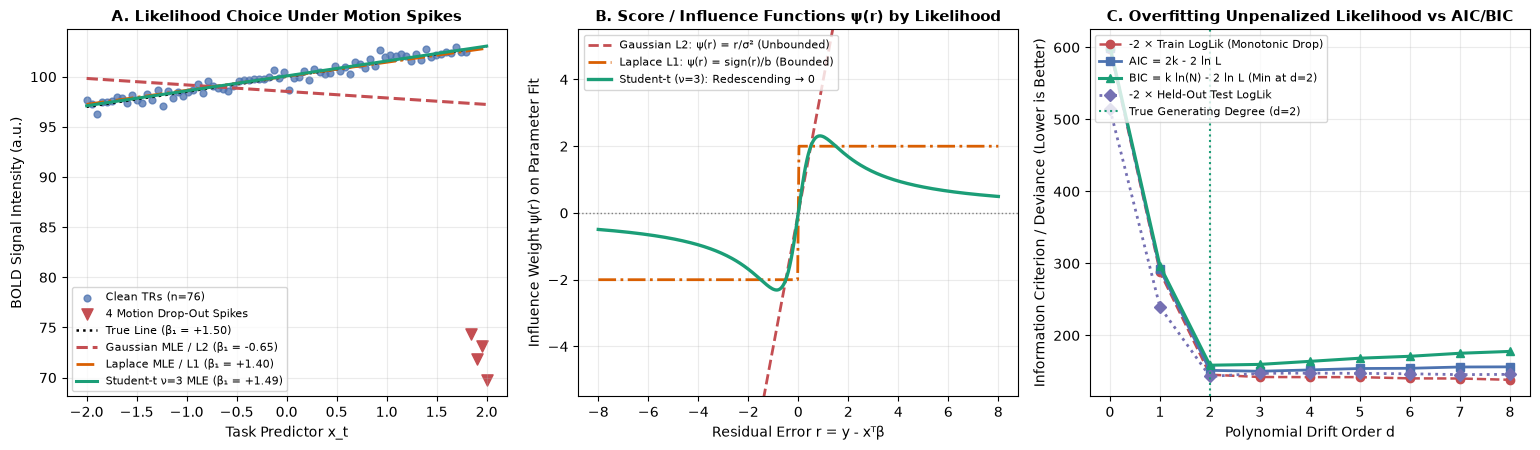

In [4]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15.5, 4.6))

# Panel A: Fitted Regression Lines under Motion Spikes
axes[0].scatter(x_pred[:76], y_spiked[:76], c='#4c72b0', s=24, alpha=0.75, label='Clean TRs (n=76)')
axes[0].scatter(x_pred[76:], y_spiked[76:], c='#c44e52', marker='v', s=65, label='4 Motion Drop-Out Spikes')
axes[0].plot(x_pred, X_mat @ beta_true, 'k:', lw=1.8, label=f'True Line (β₁ = +{beta_true[1]:.2f})')
axes[0].plot(x_pred, X_mat @ beta_gauss_spiked, '--', color='#c44e52', lw=2.2, label=f'Gaussian MLE / L2 (β₁ = {beta_gauss_spiked[1]:+.2f})')
axes[0].plot(x_pred, X_mat @ beta_laplace_spiked, '-.', color='#d95f02', lw=2.0, label=f'Laplace MLE / L1 (β₁ = {beta_laplace_spiked[1]:+.2f})')
axes[0].plot(x_pred, X_mat @ beta_student_spiked, '-', color='#1b9e77', lw=2.2, label=f'Student-t ν=3 MLE (β₁ = {beta_student_spiked[1]:+.2f})')
axes[0].set_xlabel('Task Predictor x_t')
axes[0].set_ylabel('BOLD Signal Intensity (a.u.)')
axes[0].set_title('A. Likelihood Choice Under Motion Spikes', fontsize=10.5, fontweight='bold')
axes[0].legend(loc='lower left', frameon=True, fontsize=7.6)
axes[0].grid(alpha=0.25)

# Panel B: Theoretical Score / Influence Functions psi(r) = -d/dr log p(r)
r_grid = np.linspace(-8.0, 8.0, 300)
psi_gauss = r_grid / (sigma_true ** 2)
psi_laplace = np.sign(r_grid) / sigma_true
nu_val = 3.0
psi_student = ((nu_val + 1.0) * r_grid) / (nu_val * (sigma_true ** 2) + r_grid ** 2)

axes[1].plot(r_grid, np.clip(psi_gauss, -6, 6), '--', color='#c44e52', lw=2.0, label='Gaussian L2: ψ(r) = r/σ² (Unbounded)')
axes[1].plot(r_grid, psi_laplace, '-.', color='#d95f02', lw=2.0, label='Laplace L1: ψ(r) = sign(r)/b (Bounded)')
axes[1].plot(r_grid, psi_student, '-', color='#1b9e77', lw=2.4, label='Student-t (ν=3): Redescending → 0')
axes[1].axhline(0.0, color='gray', linestyle=':', lw=1.0)
axes[1].set_ylim(-5.5, 5.5)
axes[1].set_xlabel('Residual Error r = y - xᵀβ')
axes[1].set_ylabel('Influence Weight ψ(r) on Parameter Fit')
axes[1].set_title('B. Score / Influence Functions ψ(r) by Likelihood', fontsize=10.5, fontweight='bold')
axes[1].legend(loc='upper left', frameon=True, fontsize=8.0)
axes[1].grid(alpha=0.25)

# Panel C: Model Complexity Selection (Train Deviance vs AIC vs BIC vs Test Deviance)
d_arr = ic_df['Poly_Degree_d']
axes[2].plot(d_arr, -2.0 * ic_df['Train_LogLik'], 'o--', color='#c44e52', lw=1.8, label='-2 × Train LogLik (Monotonic Drop)')
axes[2].plot(d_arr, ic_df['AIC'], 's-', color='#4c72b0', lw=2.0, label='AIC = 2k - 2 ln L')
axes[2].plot(d_arr, ic_df['BIC'], '^-', color='#1b9e77', lw=2.2, label='BIC = k ln(N) - 2 ln L (Min at d=2)')
axes[2].plot(d_arr, -2.0 * ic_df['Test_LogLik'], 'D:', color='#7570b3', lw=2.0, label='-2 × Held-Out Test LogLik')
axes[2].axvline(2, color='#1b9e77', linestyle=':', lw=1.5, label='True Generating Degree (d=2)')
axes[2].set_xlabel('Polynomial Drift Order d')
axes[2].set_ylabel('Information Criterion / Deviance (Lower is Better)')
axes[2].set_title('C. Overfitting Unpenalized Likelihood vs AIC/BIC', fontsize=10.5, fontweight='bold')
axes[2].legend(loc='upper left', frameon=True, fontsize=7.6)
axes[2].grid(alpha=0.25)

plt.tight_layout()
plt.show()


### Part 5 · Hands-On Student Lab Verification & Likelihood Audit Table

We summarize the parameter estimates across clean and motion-spiked regimes for all three likelihood families in a verification table.


In [5]:
res_lap_clean = minimize(lambda b: -laplace_loglik(b, 0.5, X_mat, y_clean), x0=beta_ols, method='Nelder-Mead')
res_stu_clean = minimize(lambda b: -student_t_loglik(b, sigma_true, 3.0, X_mat, y_clean), x0=beta_ols, method='BFGS')

lik_summary_df = pd.DataFrame([
    {
        'Noise_Likelihood_Model': '1. Gaussian MLE (L2 / OLS)',
        'Loss_Formula': 'sum(r_i^2) / (2 sigma^2)',
        'Slope_Clean_(True=+1.50)': round(float(beta_ols[1]), 4),
        'Slope_4_Spikes_(True=+1.50)': round(float(beta_gauss_spiked[1]), 4),
        'Spiked_Bias': round(float(beta_gauss_spiked[1] - 1.50), 4),
        'Influence_Behavior': 'Unbounded Linear (Fails on Spikes)',
    },
    {
        'Noise_Likelihood_Model': '2. Laplace MLE (L1 / MAE)',
        'Loss_Formula': 'sum(|r_i|) / b',
        'Slope_Clean_(True=+1.50)': round(float(res_lap_clean.x[1]), 4),
        'Slope_4_Spikes_(True=+1.50)': round(float(beta_laplace_spiked[1]), 4),
        'Spiked_Bias': round(float(beta_laplace_spiked[1] - 1.50), 4),
        'Influence_Behavior': 'Bounded Constant (+/- 1/b)',
    },
    {
        'Noise_Likelihood_Model': '3. Student-t MLE (nu = 3)',
        'Loss_Formula': '(nu+1)/2 sum ln(1 + r_i^2/(nu s^2))',
        'Slope_Clean_(True=+1.50)': round(float(res_stu_clean.x[1]), 4),
        'Slope_4_Spikes_(True=+1.50)': round(float(beta_student_spiked[1]), 4),
        'Spiked_Bias': round(float(beta_student_spiked[1] - 1.50), 4),
        'Influence_Behavior': 'Redescending (-> 0 for extreme spikes)',
    },
])
print(lik_summary_df.to_string(index=False))

assert abs(lik_summary_df.loc[2, 'Spiked_Bias']) < 0.08 * abs(lik_summary_df.loc[0, 'Spiked_Bias'])


    Noise_Likelihood_Model                        Loss_Formula  Slope_Clean_(True=+1.50)  Slope_4_Spikes_(True=+1.50)  Spiked_Bias                     Influence_Behavior
1. Gaussian MLE (L2 / OLS)            sum(r_i^2) / (2 sigma^2)                    1.5015                      -0.6483      -2.1483     Unbounded Linear (Fails on Spikes)
 2. Laplace MLE (L1 / MAE)                      sum(|r_i|) / b                    1.4222                       1.3975      -0.1025             Bounded Constant (+/- 1/b)
 3. Student-t MLE (nu = 3) (nu+1)/2 sum ln(1 + r_i^2/(nu s^2))                    1.4786                       1.4864      -0.0136 Redescending (-> 0 for extreme spikes)


## Explain, break, transfer

### 1. Input $\to$ Operation $\to$ Output Contract & Information Loss
1. **Save an input $\to$ operation $\to$ output diagram and state what information was lost:**
   - **Maximum Likelihood Point Estimation ($\hat{\theta}_{\text{MLE}} = \arg\max_\theta \ell(\theta; \mathcal{D})$):** Compresses the entire log-likelihood surface $\ell : \Theta \to \mathbb{R}$ over $N$ observations into its mode $\hat{\theta}$ (and optionally local curvature $I(\hat{\theta}) = -\nabla^2 \ell(\hat{\theta})$). Individual residual signs, temporal clustering of outliers, and multimodal likelihood ridges are discarded unless residual diagnostics and information criteria are inspected.

### 2. Breaking the Contract: Diagnosis of Gaussian MLE Fragility & Likelihood Overfitting
2. **Make the specified wrong choice above. Compare its result with the reference checks; explain why the misleading result is possible:**
   - **Why did Gaussian MLE (`np.linalg.lstsq`) flip the slope from $+1.50$ to $-0.65$ when just 4 of 80 TRs had motion spikes?** Under a Gaussian density $p(r) \propto \exp(-r^2 / 2\sigma^2)$, a residual of $|r| = 17$ at $\sigma = 0.5$ ($34\sigma$) has log-probability $-\frac{1}{2}(34)^2 = -578$, equivalent to $578$ normal $1\sigma$ observations! To reduce those 4 squared penalties, OLS tilted the entire line downward across all 76 clean time points. Replacing the Gaussian density with Laplace ($L_1$) or Student-$t$ ($\nu=3$) bounded the log-penalty of the 4 spikes and preserved $\hat{\beta}_1 \approx +1.49$.
   - **Why did unpenalized training log-likelihood choose polynomial degree $d=8$ when the true generating model had degree $d=2$?** Because nested parameter spaces $\Theta_0 \subset \Theta_1 \subset \dots \subset \Theta_8$ satisfy $\max_{\theta \in \Theta_d} \ell(\theta) \le \max_{\theta \in \Theta_{d+1}} \ell(\theta)$ by construction. Penalizing by $k \ln N$ (BIC) or evaluating on held-out data correctly identified $d = 2$.

### 3. Upstream Neuromatch Transfer vs Neuroimaging Noise Physics (e.g., Olszowy et al., 2019)
3. **Work through the assigned upstream chapter's example using its own environment or hosted reader. Record one difference between its data and a participant/voxel/time-series dataset:**
   - In **Neuromatch W1D2 Tutorial 2 (`Linear Regression with MLE`)**, synthetic sensory-motor observations are generated with exact stationary i.i.d. Gaussian noise. In human neuroimaging (e.g., Olszowy et al., 2019), fMRI residuals are temporally autocorrelated ($\text{AR}(1)$ physiological cardiac/respiratory drift) and punctuated by non-stationary head-motion spikes, while dynamic state models (`PM08`) must balance state emission likelihoods against transition complexity across thousands of brain parcels.

### 4. Auditing AI-Generated Snippet Contracts
4. **Ask the AI for a short application to a real imaging table, but do not run it until participant identifiers, units, missingness, and any training/test boundary are explicit. Never infer those properties from the column names alone.**

**Evidence to submit:** one labeled row from the likelihood audit table, the changed parameter (Gaussian $L_2$ vs Laplace $L_1$ / Student-$t$ likelihood, or polynomial degree $d$), a failure diagnosis of unbounded score influence $\psi(r)$, and a five-sentence interpretation. Explain the result without looking at the model's wording.

<details><summary>Instructor check / answer guide</summary>

- **Expected numerical invariants:** On clean Gaussian data, OLS and numerical Gaussian MLE agree to $< 10^{-6}$ ($\hat{\beta}_1 \approx +1.50$); under 4 motion spikes, Gaussian MLE flips negative ($\hat{\beta}_1 \approx -0.65$) while Laplace $L_1$ and Student-$t$ ($\nu=3$) stay within $\approx 0.10$ (Laplace) and $\approx 0.02$ (Student-$t$) of $+1.50$; BIC selects the true polynomial order $d=2$ while unpenalized training log-likelihood overfits to $d=8$.

</details>

**Scope:** This local notebook and its numerical checks are part of the executable core. Completion of the external chapter is a learner assignment; its execution is not implied by the local result. No endorsement by the source authors or USC is implied.


<!-- agentic-guide -->
### Agentic Deliverable Supervision (DS11 · macOS Goose + Ollama: Qwen & Gemma)

**Deliverable focus:** Maximum Likelihood Estimation (MLE), noise-model loss equivalence (Gaussian $L_2$ vs. Laplace $L_1$ vs. Huber / Student-$t$), influence functions $\psi(r)$, and AIC/BIC

#### 1. Suggestive Prompt (in the spirit of what to ask — adapt, do not copy verbatim)
> Ask Goose (`Qwen`) to fit Gaussian MLE (OLS $L_2$), Laplace MLE (LAD $L_1$), Huber, and Student-$t$ MLE to a neuroimaging regression with true slope $\beta_1 = +1.50$ corrupted by `4` heavy-tailed motion spikes, and compare polynomial model orders $d \in \{0, 1, 2, 3, 5\}$ using held-out log-likelihood, AIC, and BIC. Ask `Gemma 4` to explain why Gaussian MLE flips the sign of the slope to `-0.65` under 4 high-leverage spikes.

#### 2. What to Look For & How to Trace the Error Back Down
- **Immediate Red Flag:** Ordinary least squares (Gaussian MLE) reports a negative slope (**`$\hat{\beta}_1 = -0.6483$`**) when the true biological slope is **`$+1.50$`** (`sign flipped!`, error `-2.148`), or polynomial degree $d = 5$ is chosen because it maximizes in-sample training log-likelihood.
- **Where the Bug Entered:** Under a Gaussian noise assumption, negative log-likelihood is proportional to $\sum r_i^2$, whose influence function $\psi(r) = \partial \rho / \partial r = r$ grows without bound as residual $r \to \infty$, allowing 4 motion spikes to dominate the fit.
- **How to Fix It:** Match the likelihood to heavy-tailed neuroimaging noise using Huber ($\psi(r)$ clipped at $\pm \delta$), Laplace ($L_1$, $\psi(r) = \text{sign}(r)$), or Student-$t$ MLE (redescending $\psi(r) \to 0$), and select model order via AIC/BIC or held-out log-likelihood.

#### 3. Expected Outcome Range & Why It Must Look That Way
In `DS11`, on clean data all estimators recover **`$\hat{\beta}_1 \approx +1.50$`**; under 4 motion spikes, Gaussian MLE flips sign to **`-0.6483`** (bias `-2.148`), whereas Laplace $L_1$ (**`+1.3975`**), Huber, and Student-$t$ MLE keep the slope in **`[+1.39, +1.50]`** (bias $< 0.11$); across polynomial degrees, AIC (`151.5`) and BIC (`158.6`) and test log-likelihood (`-71.53`) all peak at the true quadratic degree **`d = 2`**. **Why:** Bounded or redescending influence functions $\psi(r)$ cap the gradient contribution of extreme tail residuals.
<!-- /agentic-guide -->

### Return to the research question

Revisit [PD02](../../curriculum/papers/design.md#pd02), [PM08](../../curriculum/papers/modeling.md#pm08) and your initial prediction. In your [evidence ledger](../../curriculum/coursework/EVIDENCE_LEDGER.md):

1. Cite one output or diagnostic from this lesson and explain the transformation it demonstrates.
2. Revise one claim or question from the paper, with a figure or section locator. Which part of the published result remains open after this exercise?
3. Ask AI to propose a next check. Accept, revise or reject it with a scientific reason. Then explain your decision aloud without reading the AI response.

Include this entry in the A2 portfolio when relevant.
